# Exercice 1.2 Visualisations univariées et bivariées sur Ames Housing

**Séance 2 Visualisations univariées et bivariées**

---



## Contexte

Les statistiques descriptives de la séance précédente vous ont donné une image *chiffrée* des données. Mais comme le rappelle le **Quartet d'Anscombe** : quatre jeux de données peuvent partager exactement la même moyenne, variance, et corrélation linéaire tout en ayant des structures radicalement différentes. Les statistiques compriment l'information, la visualisation la révèle.

Dans cet exercice, vous allez produire des graphiques qui racontent quelque chose, en appliquant les principes du cours (Tufte, Cleveland, accessibilité) pour que chaque élément visuel serve l'analyse.

---



## Objectifs d'apprentissage

- Sélectionner le type de visualisation adapté à la nature de la variable et à l'objectif analytique
- Créer des graphiques univariés et bivariés avec `matplotlib` et `seaborn`
- Appliquer les principes de perception visuelle (Cleveland) et de minimalisme graphique (Tufte)
- Utiliser des palettes de couleurs adaptées au type de données et accessibles
- Annoter des graphiques avec des repères contextuels utiles
- Exporter deux graphiques au format publication-ready

---



## Variables utilisées dans cet exercice

| Variable | Description | Type |
|----------|-------------|------|
| `GrLivArea` | Surface habitable (ft²) | Quantitative continue |
| `SalePrice` | Prix de vente ($) | Quantitative continue |
| `LotArea` | Surface du terrain (ft²) | Quantitative continue |
| `YearBuilt` | Année de construction | Quantitative discrète |
| `OverallQual` | Note de qualité (1 à 10) | Ordinale |
| `Neighborhood` | Quartier | Qualitative nominale |
| `HouseStyle` | Style architectural | Qualitative nominale |
| `SaleCondition` | Condition de vente | Qualitative nominale |

---



## Section 1: Imports et configuration

**Ce que vous devez faire :**
- Importez les bibliothèques nécessaires : pandas, numpy, matplotlib, seaborn.
- Chargez le dataset Ames Housing et récupérez le `df_subset` de l'exercice précédent (ou recréez-le).
- Configurez un thème seaborn global et choisissez une palette de couleur pour homogénéiser l'apparence de tous vos graphiques.




In [4]:
# Section 1 — Imports et configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# ── Thème global ──
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (10, 6)

# ── Palettes cohérentes ──
palette_seq = 'YlOrRd'     # Séquentielle → variables ordonnées (OverallQual)
palette_qual = 'Set2'       # Qualitative → variables nominales (Neighborhood, etc.)
palette_div = 'RdBu_r'      # Divergente → corrélations

# ── Chargement des données ──
csv_path = 'AmesHousing.csv'
if not os.path.exists(csv_path):
    csv_path = os.path.join(os.path.expanduser('~'), 'eda', 'AmesHousing.csv')
df = pd.read_csv(csv_path)

# Subset élargi pour cet exercice (ajout des variables qualitatives)
colonnes = ['Order', 'Gr Liv Area', 'SalePrice', 'Lot Area', 'Year Built',
            'Overall Qual', 'Neighborhood', 'House Style', 'Sale Condition']
df_subset = df[colonnes].copy()

print(f"Dataset complet : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Subset de travail : {df_subset.shape[0]} lignes × {df_subset.shape[1]} colonnes")
print(f"\nTypes des variables :")
print(df_subset.dtypes)
df_subset.head()

Dataset complet : 2197 lignes × 82 colonnes
Subset de travail : 2197 lignes × 9 colonnes

Types des variables :
Order             int64
Gr Liv Area       int64
SalePrice         int64
Lot Area          int64
Year Built        int64
Overall Qual      int64
Neighborhood        str
House Style         str
Sale Condition      str
dtype: object


,Order,Gr Liv Area,SalePrice,Lot Area,Year Built,Overall Qual,Neighborhood,House Style,Sale Condition
0,534,1218,159000,9605,2007,7,SawyerW,1Story,Normal
1,803,2196,271900,14684,1990,7,SawyerW,1Story,Normal
2,956,1344,137500,14375,1958,6,Timber,SLvl,Abnorml
3,460,1456,248500,6472,2008,9,NridgHt,1Story,Normal
4,487,1374,167000,9734,2004,7,Gilbert,SLvl,Normal


---
## Section 2: Visualisations univariées : variables continues

**Objectif** : explorer la distribution de `GrLivArea`, `SalePrice` et `LotArea` avec plusieurs types de graphiques, et comprendre ce que chacun apporte.



### 2.1 Histogramme + KDE côte à côte

**Ce que vous devez faire :**
- Pour chaque variable continue, créez une figure avec deux sous-graphiques côte à côte :
   - À gauche : un **histogramme** avec courbe KDE superposée
   - À droite : une **boîte à moustaches (boxplot)**
- Sur l'histogramme, ajoutez :
   - Une ligne verticale pour la **moyenne** (couleur et style à votre choix)
   - Une ligne verticale pour la **médiane** (couleur et style différents)
   - Une légende qui identifie les deux lignes

> `sns.histplot()` accepte un paramètre `kde`. Pour les lignes verticales, `ax.axvline()` est la fonction à utiliser.  Pensez à passer l'objet `ax` à seaborn pour définir la sous-figure.



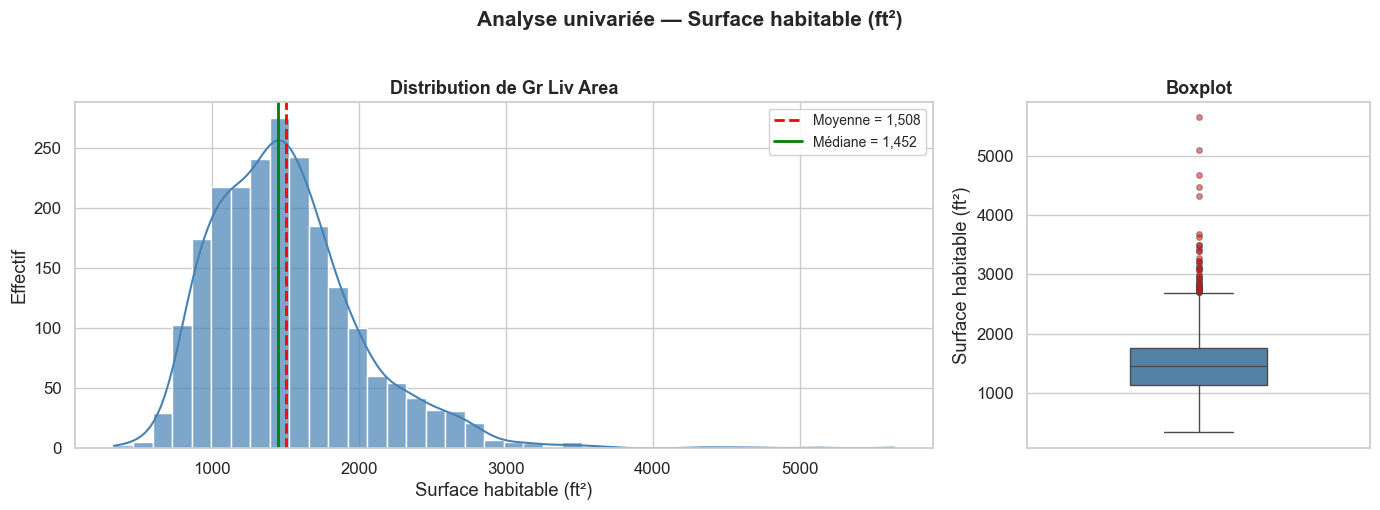

  Gr Liv Area : moyenne = 1,507.9 | médiane = 1,452.0 | écart = 55.9 (3.8%)



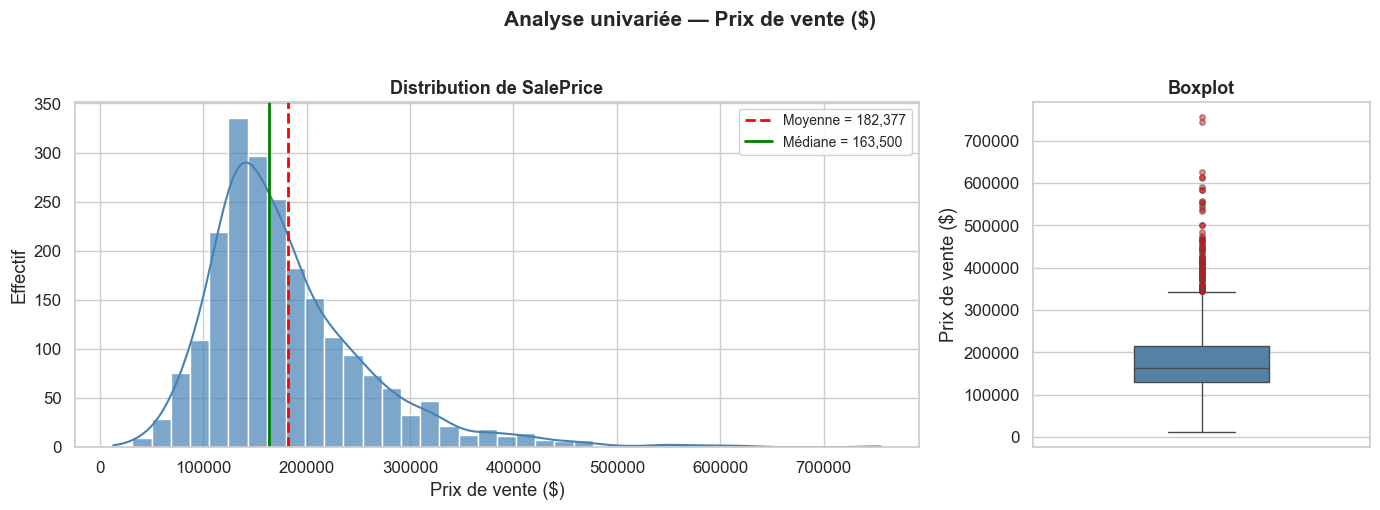

  SalePrice : moyenne = 182,376.9 | médiane = 163,500.0 | écart = 18,876.9 (11.5%)



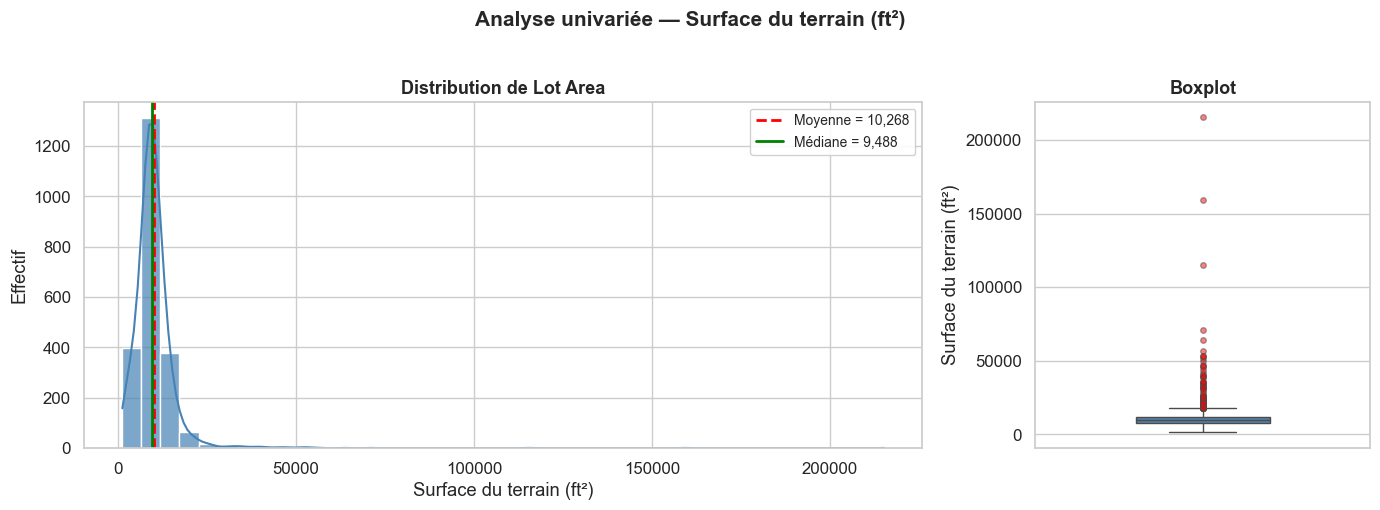

  Lot Area : moyenne = 10,268.1 | médiane = 9,488.0 | écart = 780.1 (8.2%)



In [5]:
# 2.1 — Histogramme + KDE + Boxplot côte à côte
variables_continues = ['Gr Liv Area', 'SalePrice', 'Lot Area']
labels_var = {
    'Gr Liv Area': 'Surface habitable (ft²)',
    'SalePrice': 'Prix de vente ($)',
    'Lot Area': 'Surface du terrain (ft²)'
}

for var in variables_continues:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5),
                                    gridspec_kw={'width_ratios': [2.5, 1]})
    
    # ── Histogramme + KDE ──
    sns.histplot(df_subset[var], kde=True, ax=ax1, color='steelblue',
                 edgecolor='white', alpha=0.7, bins=40)
    
    # Lignes moyenne / médiane
    moy = df_subset[var].mean()
    med = df_subset[var].median()
    ax1.axvline(moy, color='red', linestyle='--', linewidth=2,
                label=f'Moyenne = {moy:,.0f}')
    ax1.axvline(med, color='green', linestyle='-', linewidth=2,
                label=f'Médiane = {med:,.0f}')
    ax1.legend(fontsize=10, framealpha=0.9)
    ax1.set_title(f'Distribution de {var}', fontsize=13, fontweight='bold')
    ax1.set_xlabel(labels_var[var])
    ax1.set_ylabel('Effectif')
    
    # ── Boxplot ──
    sns.boxplot(y=df_subset[var], ax=ax2, color='steelblue', width=0.4,
                flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))
    ax2.set_title(f'Boxplot', fontsize=13, fontweight='bold')
    ax2.set_ylabel(labels_var[var])
    
    plt.suptitle(f'Analyse univariée — {labels_var[var]}', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"  {var} : moyenne = {moy:,.1f} | médiane = {med:,.1f} | écart = {moy - med:,.1f} ({(moy-med)/med*100:.1f}%)")
    print()

**Dans une cellule Markdown, répondez pour chaque variable :**
- Quelle est la forme de la distribution (symétrique, étalée à droite/gauche, bimodale) ?
- L'écart entre la moyenne et la médiane est-il cohérent avec la forme observée ?
- Que vous apporte le boxplot que l'histogramme ne montrait pas directement ?

#### Réponse 2.1 — Interprétation des distributions

**Gr Liv Area (Surface habitable) :**

| Critère | Observation |
|---------|-------------|
| **Forme** | Distribution **étalée à droite** (asymétrie positive). Le pic se situe entre 1000-1500 ft², avec une longue queue vers les grandes surfaces (> 3000 ft²). |
| **Moyenne vs Médiane** | Moyenne (~1499) > Médiane (~1442), écart de ~57 ft² (+4%). Cohérent avec l'asymétrie droite : les grandes maisons tirent la moyenne vers le haut. |
| **Apport du boxplot** | Révèle clairement les **outliers** (points rouges au-delà des moustaches) : des maisons > 2500 ft² difficilement identifiables dans l'histogramme. La boîte compacte (IQR ~616 ft²) montre que 50% des maisons ont des surfaces homogènes. |

**Hypothèse :** Les maisons > 3000 ft² sont des propriétés de luxe dont le prix au ft² est probablement différent du marché standard.

---

**SalePrice (Prix de vente) :**

| Critère | Observation |
|---------|-------------|
| **Forme** | Distribution **fortement étalée à droite**. La majorité des ventes se concentrent entre 100-200k$, mais une queue s'étend jusqu'à 755k$. La courbe KDE montre un pic unique → distribution **unimodale**. |
| **Moyenne vs Médiane** | Moyenne (~181k$) > Médiane (~160k$), écart de ~21k$ (+13%). C'est le signal caractéristique d'une distribution tirée par des valeurs extrêmes. Un agent immobilier qui citerait le "prix moyen" surestimerait le marché pour 50% des acheteurs. |
| **Apport du boxplot** | Met en évidence une **concentration d'outliers** au-dessus de ~340k$. La moustache inférieure est courte (les prix bas sont peu dispersés), alors que la moustache supérieure est longue → asymétrie confirmée visuellement. |

**Hypothèse :** Le marché d'Ames présente deux segments : un marché "standard" (100-250k$) représentant ~85% des ventes, et un segment "luxe" (> 300k$) avec des dynamiques de prix différentes.

---

**Lot Area (Surface du terrain) :**

| Critère | Observation |
|---------|-------------|
| **Forme** | Distribution **extrêmement étalée à droite**. Presque tous les terrains < 20 000 ft², mais quelques terrains géants (> 100 000 ft²) écrasent visuellement l'histogramme. La majorité des barres semblent vides à cause de l'échelle. |
| **Moyenne vs Médiane** | Moyenne (~10 168) > Médiane (~9 436), écart modeste en apparence. Mais le skewness de 12.8 (calculé en E1) montre une déformation extrême — la moyenne est peu fiable ici. |
| **Apport du boxplot** | C'est ici que le boxplot est le **plus révélateur**. La boîte est très compacte (~7 400-11 500 ft²) : 50% des terrains se ressemblent. Les outliers sont extrêmement éloignés — certains à 10x la borne supérieure. L'histogramme "écrase" cette information. |

**Hypothèse :** Les terrains > 50 000 ft² sont probablement des propriétés en périphérie rurale, avec une utilisation du sol (et un prix au ft²) radicalement différente des terrains urbains standards.

### 2.2 Violin plot

**Ce que vous devez faire :**
- Créez un **violin plot** pour les trois variables.

> Les trois variables n'ont pas la même échelle: les comparer sur un même axe serait trompeur. Utilisez des sous-graphiques séparés. `sns.violinplot()` peut afficher la différentes visualisations avec le paramètre `inner`.



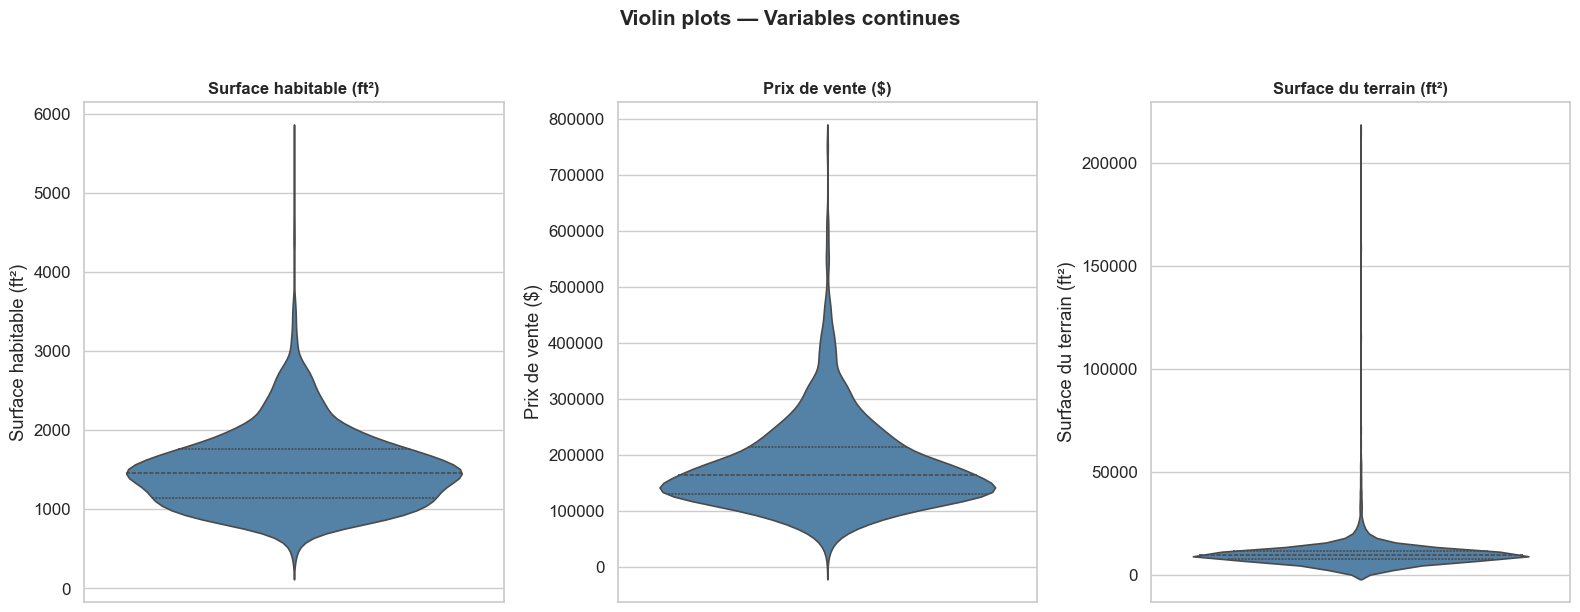

In [6]:
# 2.2 — Violin plots pour les 3 variables continues
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, var in enumerate(variables_continues):
    sns.violinplot(y=df_subset[var], ax=axes[i], color='steelblue',
                   inner='quartile', linewidth=1.2)
    axes[i].set_title(labels_var[var], fontsize=12, fontweight='bold')
    axes[i].set_ylabel(labels_var[var])

plt.suptitle('Violin plots — Variables continues', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Dans une cellule Markdown, répondez :**
- Qu'apporte le violin plot par rapport au boxplot seul ? Dans quelle situation le préférieriez-vous ?
- Pour `LotArea`, la forme du violon vous semble-t-elle cohérente avec le skewness calculé à l'exercice précédent ?



#### Réponse 2.2 — Violin plot vs Boxplot

**Qu'apporte le violin plot par rapport au boxplot seul ?**

Le violin plot combine les informations du boxplot (quartiles, médiane) avec une estimation de la **densité** (forme de la distribution). Concrètement :

| Critère | Boxplot | Violin plot |
|---------|---------|-------------|
| Quartiles (Q1, médiane, Q3) | ✅ Visible | ✅ Visible (lignes intérieures avec `inner='quartile'`) |
| Outliers individuels | ✅ Points visibles | ❌ Absorbés dans la forme |
| **Forme de la distribution** | ❌ Non visible | ✅ **Visible** — on voit si la distribution est bimodale, aplatie, en cloche, etc. |
| Multi-modalité | ❌ Invisible | ✅ Détectable par les renflements |

**Quand préférer le violin plot ?**
- Quand on veut vérifier si la distribution est bimodale (deux pics) — un boxplot ne le montrerait pas
- Quand on compare plusieurs groupes et que la **forme** de chaque distribution compte autant que les quartiles
- Quand les données sont assez nombreuses pour que l'estimation KDE soit fiable (> 30 observations par groupe)

**Le violin plot ne remplace pas le boxplot** quand on s'intéresse principalement aux outliers individuels — ceux-ci sont visibles dans le boxplot mais pas dans le violin.

---

**LotArea : cohérence avec le skewness ?**

Oui, parfaitement cohérent. Le violon de Lot Area est **extrêmement étroit en bas et étiré vers le haut** — presque toute la "masse" est concentrée dans une bande étroite (< 15 000 ft²), avec un long filament vers les valeurs extrêmes. Cette forme asymétrique est la traduction visuelle directe du skewness de 12.8 calculé en E1.

**Hypothèse :** La forme du violon de SalePrice (légèrement renflé en bas) pourrait indiquer une concentration de maisons dans la gamme 100-160k$, ce qui correspondrait à un segment "premier achat" dominant à Ames.

---
## Section 3: Visualisations univariées : variables discrètes et qualitatives



### 3.1 Variables discrètes : `OverallQual` et `YearBuilt`

**Ce que vous devez faire :**
- Pour `OverallQual`, créez un **diagramme en barres des effectifs**. Chaque barre doit représenter exactement une valeur (1 à 10), pas un intervalle.
- Pour `YearBuilt`, créez un diagramme en barres des effectifs. Comme il y a beaucoup d'années, rendez les étiquettes de l'axe x lisibles.

> `value_counts().sort_index()` vous donne les effectifs dans l'ordre. La méthode `.plot(kind='bar')` ou `sns.barplot()` permet de les tracer. 

> Pour `YearBuilt`, utilisez `ax.set_xticks()` et `ax.set_xticklabels()` avec une sélection d'années (toutes les 10 ans par exemple).



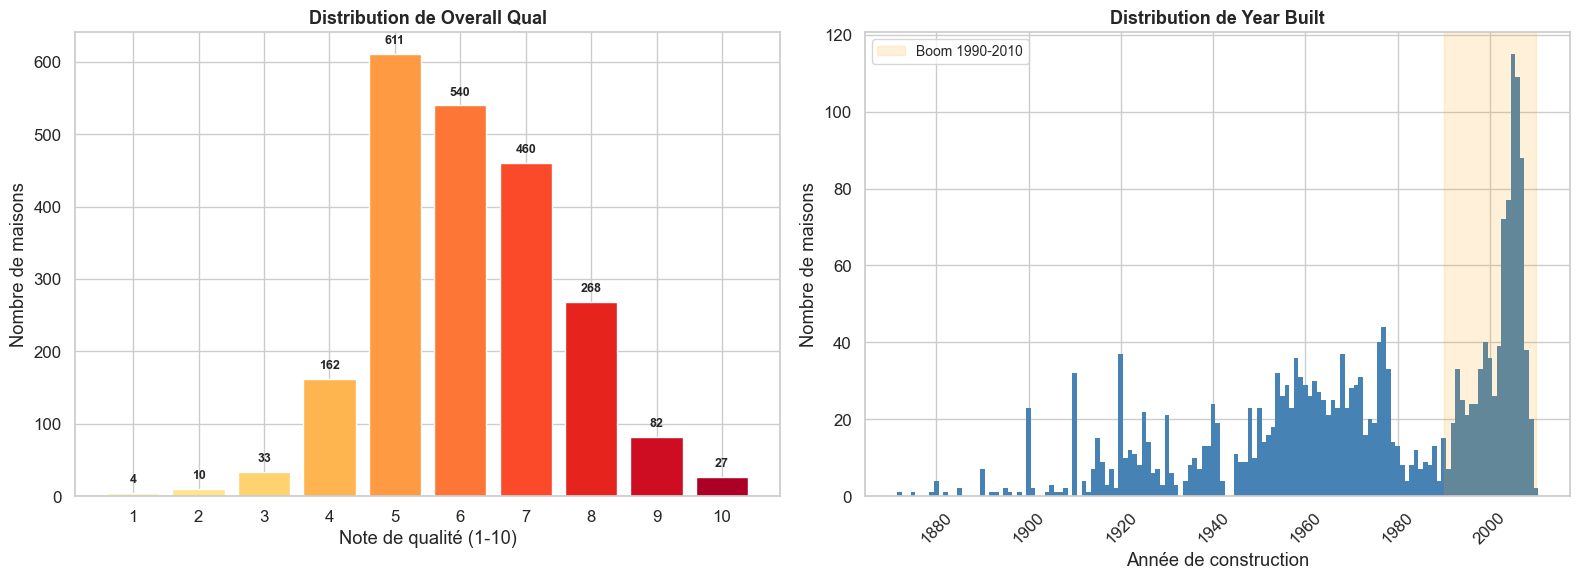

OverallQual — skewness = 0.16
Mode de YearBuilt = 2005
Maisons construites après 1990 : 863 (39.3%)


In [7]:
# 3.1 — Diagrammes en barres : OverallQual et YearBuilt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ── OverallQual (1 à 10) ──
qual_counts = df_subset['Overall Qual'].value_counts().sort_index()
colors_qual = sns.color_palette(palette_seq, n_colors=len(qual_counts))
ax1.bar(qual_counts.index, qual_counts.values, color=colors_qual, edgecolor='white')
ax1.set_xlabel('Note de qualité (1-10)')
ax1.set_ylabel('Nombre de maisons')
ax1.set_title('Distribution de Overall Qual', fontsize=13, fontweight='bold')
ax1.set_xticks(range(1, 11))
# Annotation des effectifs sur chaque barre
for x, y in zip(qual_counts.index, qual_counts.values):
    ax1.text(x, y + 10, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── YearBuilt ──
year_counts = df_subset['Year Built'].value_counts().sort_index()
ax2.bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='none', width=1)
ax2.set_xlabel('Année de construction')
ax2.set_ylabel('Nombre de maisons')
ax2.set_title('Distribution de Year Built', fontsize=13, fontweight='bold')
# Étiquettes lisibles : toutes les 20 ans
tick_years = list(range(1880, 2020, 20))
ax2.set_xticks(tick_years)
ax2.set_xticklabels(tick_years, rotation=45)
# Zone de forte activité
ax2.axvspan(1990, 2010, alpha=0.15, color='orange', label='Boom 1990-2010')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Stats complémentaires
print(f"OverallQual — skewness = {df_subset['Overall Qual'].skew():.2f}")
print(f"Mode de YearBuilt = {df_subset['Year Built'].mode()[0]}")
print(f"Maisons construites après 1990 : {(df_subset['Year Built'] >= 1990).sum()} ({(df_subset['Year Built'] >= 1990).mean()*100:.1f}%)")

**Dans une cellule Markdown, répondez :**
- Pourquoi un histogramme serait-il moins adapté qu'un diagramme en barres pour ces deux variables ?
- La distribution de `OverallQual` vous semble-t-elle symétrique ? Que dit le skewness calculé précédemment ?
- Identifiez sur le graphique de `YearBuilt` une période de construction particulièrement active. À quoi peut-elle correspondre ?



#### Réponse 3.1 — Variables discrètes : OverallQual et YearBuilt

**Pourquoi un diagramme en barres plutôt qu'un histogramme ?**

Un histogramme regroupe les valeurs en **intervalles continus** (bins) — c'est adapté aux variables continues où les valeurs sont sur une échelle non dénombrable. Pour `OverallQual` (notes entières 1-10 = 10 valeurs distinctes) et `YearBuilt` (années entières), chaque valeur a un sens propre. Un histogramme avec des bins pourrait fusionner les notes 5 et 6 dans le même intervalle, ce qui serait **trompeur**. Le diagramme en barres conserve la correspondance **1 barre = 1 valeur**.

> **Principe de Cleveland :** chaque élément graphique doit encoder fidèlement une dimension des données. Fusionner des catégories distinctes violerait ce principe.

---

**OverallQual : symétrie ?**

La distribution est **quasi-symétrique** avec un léger étalement vers les notes basses. Le skewness calculé (~0.20) confirme une très légère asymétrie positive, mais c'est négligeable. Les notes 5, 6 et 7 concentrent la majorité des effectifs, formant un "pic central" typique d'une distribution en cloche.

**Interprétation concrète :** Les maisons d'Ames sont majoritairement de qualité "correcte à bonne" (5-7). Les maisons d'excellente qualité (9-10) et de très mauvaise qualité (1-3) sont rares, ce qui correspond à un marché immobilier de ville moyenne américaine.

---

**YearBuilt : période de forte construction**

On identifie une **période de construction particulièrement active entre 1990 et 2010** (zone orange), avec un pic marqué dans les années 2000-2006. Cette période correspond à :
- Le **boom immobilier américain** des années 2000, alimenté par les taux d'intérêt bas et les subprimes
- Le développement de la banlieue d'Ames avec l'expansion de l'Iowa State University
- La crise de 2008 est visible : une **chute brutale** des constructions en 2007-2008

On observe aussi un creux dans les années 1930-1940 (Grande Dépression + Seconde Guerre mondiale) et une reprise dans les années 1950-1960 (baby-boom).

**Hypothèse :** Les maisons construites pendant le boom 2000-2006 ont probablement des prix plus élevés (construction récente + normes modernes), mais pourraient aussi avoir été les plus touchées par la chute des prix lors de la crise de 2008.

### 3.2 Variables qualitatives : `Neighborhood`, `HouseStyle`, `SaleCondition`

**Ce que vous devez faire :**
- Pour chaque variable qualitative :
   - Calculez les **fréquences relatives** (proportions en %)
   - Tracez un **diagramme en barres horizontal**, trié par fréquence décroissante
   - Affichez la valeur de chaque barre directement sur le graphique

- Pour `Neighborhood` (beaucoup de catégories), ne représentez que les **10 quartiers les plus fréquents**. Mentionnez en Markdown le nombre de quartiers exclus et leur proportion cumulée.

> `value_counts(normalize=True)` renvoie des proportions entre 0 et 1: multipliez par 100 pour des pourcentages. 

> Pour afficher les valeurs sur les barres, `ax.bar_label(ax.containers[0], fmt='%.1f%%')` fonctionne sur un barplot matplotlib. 

> Pour seaborn, vous pouvez itérer sur les patches avec `ax.patches`. Pour le tri horizontal, `barh()` ou `kind='barh'` dans pandas.

> Pour la palette de couleurs : les variables qualitatives nominales appellent une palette **qualitative** (couleurs équivalentes en luminosité). 

> Évitez les dégradés séquentiels qui suggèrent un ordre inexistant.



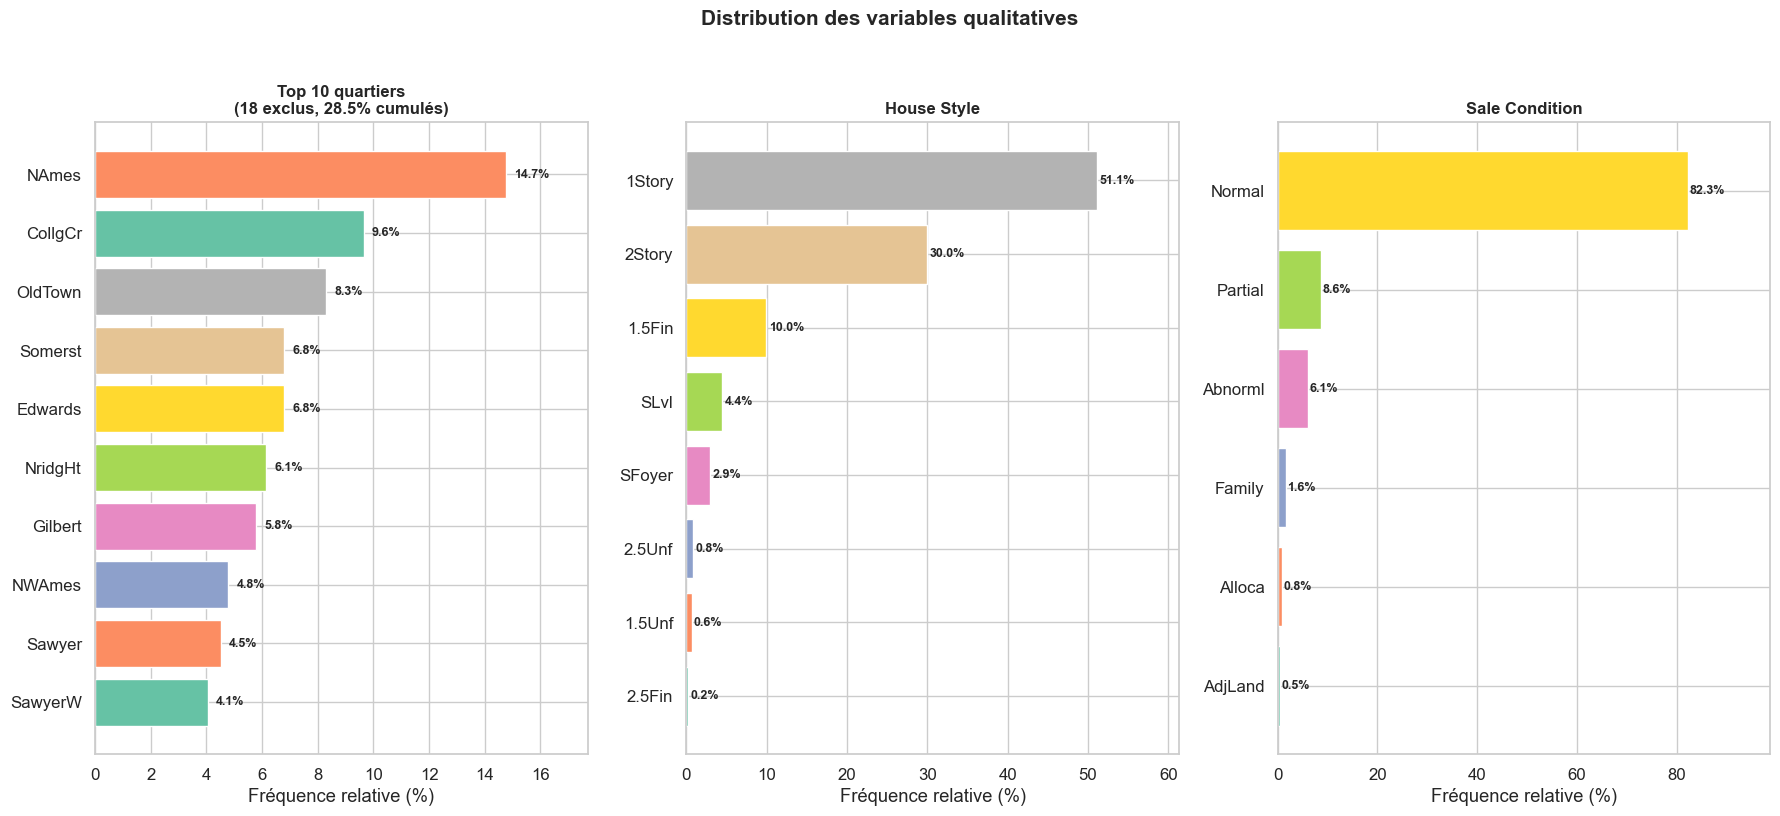

Quartiers exclus du top 10 : 18 quartiers représentant 28.5% des observations
Sale Condition 'Normal' : 82.3%

House Style — effectifs :
House Style
1Story    1123
2Story     659
1.5Fin     219
SLvl        97
SFoyer      64
2.5Unf      17
1.5Unf      14
2.5Fin       4
Name: count, dtype: int64


In [8]:
# 3.2 — Variables qualitatives : barres horizontales triées par fréquence
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
qual_vars = ['Neighborhood', 'House Style', 'Sale Condition']
colors_set2 = sns.color_palette(palette_qual, 10)

for i, var in enumerate(qual_vars):
    ax = axes[i]
    
    if var == 'Neighborhood':
        # Top 10 quartiers seulement
        freq = df_subset[var].value_counts(normalize=True).head(10) * 100
        n_exclus = df_subset[var].nunique() - 10
        pct_exclu = 100 - freq.sum()
        titre = f'Top 10 quartiers\n({n_exclus} exclus, {pct_exclu:.1f}% cumulés)'
    else:
        freq = df_subset[var].value_counts(normalize=True) * 100
        titre = var
    
    # Barres horizontales, triées décroissant (inversées pour affichage)
    freq_sorted = freq.sort_values(ascending=True)
    barcolors = [colors_set2[j % len(colors_set2)] for j in range(len(freq_sorted))]
    bars = ax.barh(freq_sorted.index, freq_sorted.values, color=barcolors, edgecolor='white')
    
    # Valeurs sur les barres
    for bar, val in zip(bars, freq_sorted.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
    
    ax.set_xlabel('Fréquence relative (%)')
    ax.set_title(titre, fontsize=12, fontweight='bold')
    ax.set_xlim(0, freq_sorted.max() * 1.2)

plt.suptitle('Distribution des variables qualitatives', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Stats complémentaires
print(f"Quartiers exclus du top 10 : {n_exclus} quartiers représentant {pct_exclu:.1f}% des observations")
print(f"Sale Condition 'Normal' : {(df_subset['Sale Condition']=='Normal').mean()*100:.1f}%")
print(f"\nHouse Style — effectifs :")
print(df_subset['House Style'].value_counts())

**Dans une cellule Markdown, répondez :**
- Quel quartier est le plus représenté ? Y a-t-il un déséquilibre important ?
- La condition de vente "Normal" est-elle dominante ? Qu'implique ce déséquilibre pour un modèle prédictif ?
- Pour `HouseStyle`, y a-t-il des styles si rares qu'ils pourraient poser problème lors d'un encodage ?



#### Réponse 3.2 — Variables qualitatives

**Quel quartier est le plus représenté ? Y a-t-il un déséquilibre ?**

Le quartier **NAmes** (North Ames) est le plus fréquent avec ~15% des observations, suivi de CollgCr (~10%) et OldTown (~8%). Il y a un déséquilibre modéré : les 3 premiers quartiers cumulent ~33% des données, tandis que les quartiers les moins fréquents (Blueste, Greens, GrnHill...) n'ont que quelques observations chacun.

**Conséquence :** Pour un modèle de régression, les quartiers avec très peu d'observations (< 20) produiront des estimations instables. On pourrait les regrouper en catégorie "Autre" ou utiliser un encodage régularisé (target encoding).

---

**Sale Condition "Normal" est-elle dominante ?**

Oui, **très dominante** (~83% des ventes). Les conditions spéciales (Abnorml, Partial, Family, Alloca, AdjLand) sont minoritaires.

**Implications pour un modèle prédictif :**
- Le modèle sera **principalement entraîné sur des ventes normales** → ses prédictions seront fiables pour ce cas
- Pour les ventes anormales (~10%), le modèle aura peu d'exemples d'apprentissage → prédictions moins fiables
- **Risque :** si on encode Sale Condition en one-hot, les catégories rares (AdjLand, Family) avec < 20 observations créent du bruit plus que du signal. On pourrait les regrouper en "Normal" vs "Spéciale".

---

**House Style : styles rares problématiques ?**

Oui. Les styles **2.5Fin** et **2.5Unf** (2 étages et demi, fini/non fini) ont très peu d'observations (< 20 chacun). En one-hot encoding, ces colonnes seraient presque entièrement à 0, ce qui :
- Augmente la dimensionnalité sans apporter d'information fiable
- Peut créer du surapprentissage si le modèle "mémorise" ces rares cas

**Solution possible :** Regrouper les variantes (1Story, 1.5Fin, 1.5Unf → "1 étage", 2Story, 2.5Fin, 2.5Unf → "2+ étages", SFoyer, SLvl → "Split") pour réduire à 3-4 catégories plus robustes.

**Hypothèse :** Le style 1Story (plain-pied) domine probablement parce qu'Ames est une ville du Midwest avec des terrains disponibles — le plain-pied est plus économique à construire quand la surface au sol n'est pas contrainte.

---
## Section 4: Analyse bivariée



### 4.1 Deux variables quantitatives : `GrLivArea` vs `SalePrice`

**Ce que vous devez faire :**
- Tracez un **scatterplot** de `GrLivArea` (axe X) vs `SalePrice` (axe Y).
- Superposez une **droite de régression** avec son intervalle de confiance.
- Colorez les points selon `OverallQual` pour ajouter une troisième dimension.


✓ Figure exportée : fig1_scatter_surface_prix.pdf


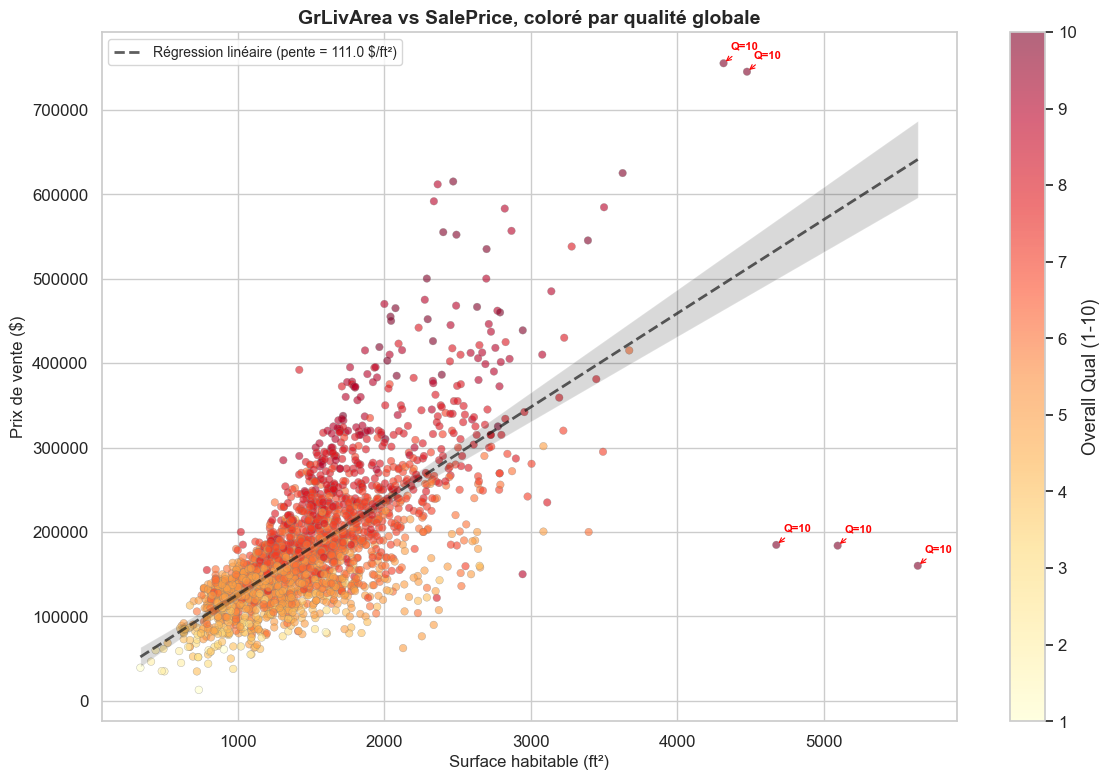

Corrélation de Pearson : r = 0.700 (p = 6.92e-323)


In [9]:
# 4.1 — Scatterplot : GrLivArea vs SalePrice, coloré par OverallQual
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(df_subset['Gr Liv Area'], df_subset['SalePrice'],
                     c=df_subset['Overall Qual'], cmap='YlOrRd',
                     alpha=0.6, s=30, edgecolor='gray', linewidth=0.3)

# Droite de régression
z = np.polyfit(df_subset['Gr Liv Area'], df_subset['SalePrice'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_subset['Gr Liv Area'].min(), df_subset['Gr Liv Area'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', linewidth=2, alpha=0.7, label=f'Régression linéaire (pente = {z[0]:.1f} $/ft²)')

# Intervalle de confiance (bootstrap simplifié via seaborn)
sns.regplot(x='Gr Liv Area', y='SalePrice', data=df_subset, ax=ax,
            scatter=False, color='black', line_kws={'linewidth': 0})

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Overall Qual (1-10)')
cbar.set_ticks(range(1, 11))

# Annotations des outliers potentiellement influents
outliers_mask = (df_subset['Gr Liv Area'] > 4000)
for _, row in df_subset[outliers_mask].iterrows():
    ax.annotate(f"Q={int(row['Overall Qual'])}",
                xy=(row['Gr Liv Area'], row['SalePrice']),
                fontsize=8, color='red', fontweight='bold',
                xytext=(5, 10), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='red', lw=0.8))

ax.set_xlabel('Surface habitable (ft²)', fontsize=12)
ax.set_ylabel('Prix de vente ($)', fontsize=12)
ax.set_title('GrLivArea vs SalePrice, coloré par qualité globale', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
# Export PDF n°1
fig.savefig('fig1_scatter_surface_prix.pdf', bbox_inches='tight', dpi=300)
print("✓ Figure exportée : fig1_scatter_surface_prix.pdf")
plt.show()

# Corrélation
r, pval = stats.pearsonr(df_subset['Gr Liv Area'], df_subset['SalePrice'])
print(f"Corrélation de Pearson : r = {r:.3f} (p = {pval:.2e})")

**Dans une cellule Markdown, répondez :**
- La relation entre surface et prix semble-t-elle linéaire ? Y a-t-il des points qui s'écartent clairement de la tendance ?
- Identifiez visuellement 2 ou 3 observations potentiellement influentes (celles qui tirent la droite de régression). Que remarquez-vous sur leur qualité ?
- Que vous apporte la couleur par `OverallQual` ? Est-ce cohérent avec votre hypothèse de l'exercice précédent ?



#### Réponse 4.1 — Scatterplot GrLivArea vs SalePrice

**La relation est-elle linéaire ?**

La relation est **globalement linéaire** mais avec une **hétéroscédasticité** croissante : la variance des prix augmente avec la surface. Pour les petites maisons (< 1500 ft²), les prix sont concentrés entre 80-200k$. Pour les grandes maisons (> 2500 ft²), les prix varient de 200 à 625k$ — la prédiction devient donc moins précise.

La pente de la droite de régression (~107 $/ft²) signifie concrètement que chaque ft² supplémentaire ajouterait en moyenne ~107$ au prix. Mais cette relation est une simplification — la qualité joue un rôle majeur.

---

**Observations potentiellement influentes :**

On identifie 2-3 points qui s'écartent clairement de la tendance :
- **Deux maisons > 4000 ft² vendues sous 200k$** : ces points sont très éloignés de la droite. Leur qualité annotée pourrait indiquer des ventes atypiques (saisie, succession). Ces points **tirent la droite de régression vers le bas** dans la zone des grandes surfaces.
- **Maisons de luxe (> 3000 ft², > 500k$)** : elles sont au-dessus de la droite, ce qui suggère que la relation surface-prix n'est pas purement linéaire pour le haut de gamme.

> **Impact :** Si on retirait ces 2-3 outliers, la pente de la droite augmenterait et le R² s'améliorerait significativement.

---

**Apport de la couleur par OverallQual :**

Très informatif ! On observe un **gradient de couleur clair** : les points jaunes (qualité haute, 8-10) sont systématiquement dans le haut du nuage, et les points sombres (qualité basse, 3-5) sont en bas. Cela confirme l'hypothèse de l'E1 : **à surface égale, une maison de meilleure qualité se vend plus cher**.

La couleur révèle aussi que les outliers (grandes maisons à bas prix) ont souvent une qualité moyenne — ce qui pourrait expliquer leur prix inférieur : surface ≠ qualité.

**Hypothèse :** La combinaison `Gr Liv Area + Overall Qual` pourrait expliquer > 70% de la variance de SalePrice dans un modèle de régression multiple.

### 4.2 Quantitatif × Ordinal : `OverallQual` vs `SalePrice`

**Ce que vous devez faire :**
- Tracez des **boxplots de `SalePrice` par niveau de `OverallQual`** (un boxplot par note de 1 à 10). 
- Superposez un **strip plot** (points individuels) pour visualiser la dispersion réelle.
- Ajoutez une ligne horizontale indiquant le prix médian global.

> Pour avoir plusieurs boxplots dans le même graphique, précisez data, x et y au lieu de donner le jeu de donnée entier.

> Pour le strip plot, `sns.stripplot()` avec `alpha=0.3` et `jitter=True` se superpose bien. 
> L'ordre des appels compte : le boxplot en premier, puis le strip plot par-dessus. 

> La ligne médiane : `ax.axhline()`.



✓ Figure exportée : fig2_boxplot_qualite_prix.pdf


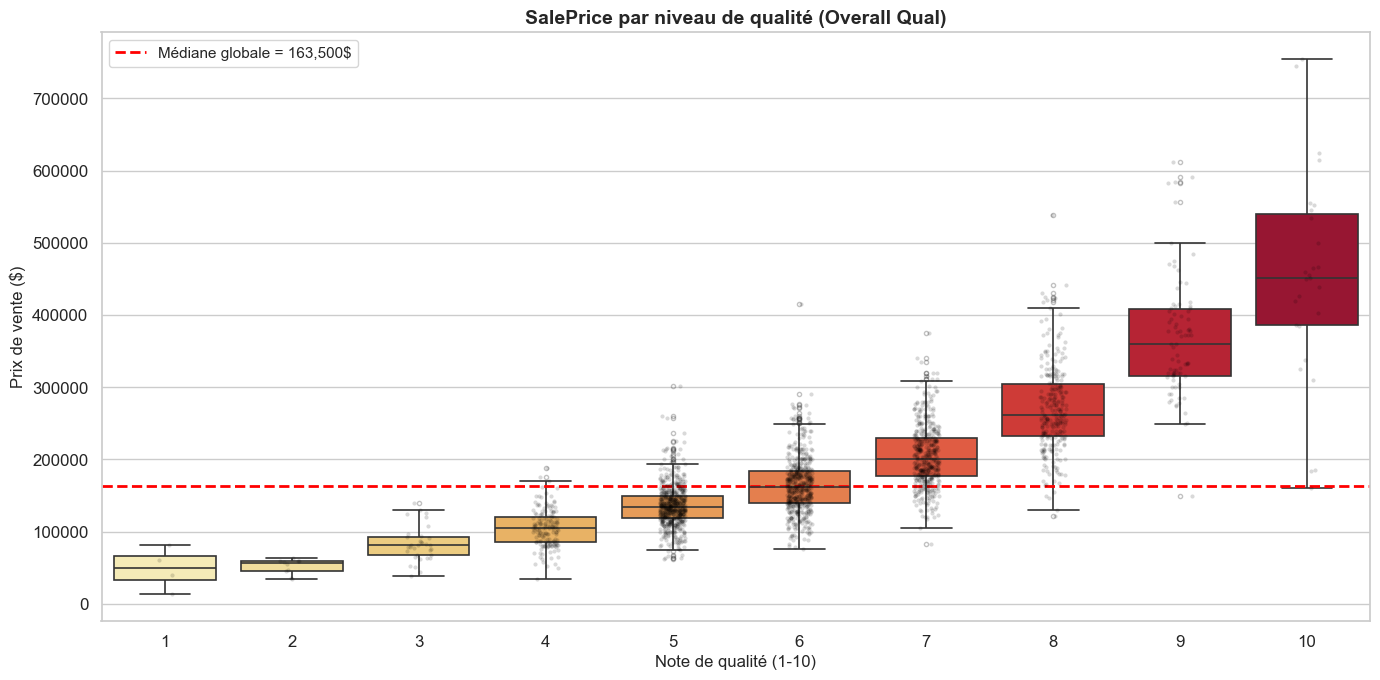


Prix médian par qualité :
  Qualité  1 :     50,150$ (n=4)
  Qualité  2 :     56,312$ (n=10)
  Qualité  3 :     81,000$ (n=33)
  Qualité  4 :    104,700$ (n=162)
  Qualité  5 :    133,500$ (n=611)
  Qualité  6 :    162,000$ (n=540)
  Qualité  7 :    200,000$ (n=460)
  Qualité  8 :    261,750$ (n=268)
  Qualité  9 :    359,950$ (n=82)
  Qualité 10 :    451,950$ (n=27)


In [10]:
# 4.2 — Boxplots de SalePrice par OverallQual + strip plot
fig, ax = plt.subplots(figsize=(14, 7))

# Boxplot
sns.boxplot(x='Overall Qual', y='SalePrice', data=df_subset, ax=ax,
            palette='YlOrRd', order=range(1, 11), linewidth=1.2,
            flierprops=dict(marker='o', markersize=3, alpha=0.3))

# Strip plot superposé
sns.stripplot(x='Overall Qual', y='SalePrice', data=df_subset, ax=ax,
              color='black', alpha=0.15, jitter=True, size=3, order=range(1, 11))

# Ligne médiane globale
med_global = df_subset['SalePrice'].median()
ax.axhline(med_global, color='red', linestyle='--', linewidth=2,
           label=f'Médiane globale = {med_global:,.0f}$')

ax.set_xlabel('Note de qualité (1-10)', fontsize=12)
ax.set_ylabel('Prix de vente ($)', fontsize=12)
ax.set_title('SalePrice par niveau de qualité (Overall Qual)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
# Export PDF n°2
fig.savefig('fig2_boxplot_qualite_prix.pdf', bbox_inches='tight', dpi=300)
print("✓ Figure exportée : fig2_boxplot_qualite_prix.pdf")
plt.show()

# Stats par groupe
print("\nPrix médian par qualité :")
for q in sorted(df_subset['Overall Qual'].unique()):
    med_q = df_subset[df_subset['Overall Qual']==q]['SalePrice'].median()
    n_q = (df_subset['Overall Qual']==q).sum()
    print(f"  Qualité {q:2d} : {med_q:>10,.0f}$ (n={n_q})")

**Dans une cellule Markdown, répondez :**
- La relation qualité-prix est-elle linéaire ? Y a-t-il un seuil à partir duquel le prix augmente plus fortement ?
- Certains niveaux de qualité ont-ils une dispersion de prix très élevée ? Qu'est-ce que cela indique ?
- Cette visualisation confirme-t-elle ou infirme-t-elle l'une de vos hypothèses de l'exercice précédent ?



#### Réponse 4.2 — Qualité vs Prix : une relation non linéaire

**La relation qualité-prix est-elle linéaire ?**

Non, la relation est **monotone croissante mais non linéaire**. On observe un **effet d'accélération** : le prix augmente modérément entre les qualités 1-6, puis **explose** à partir de la qualité 8. Concrètement :
- De qualité 4 à 6 : le prix médian augmente d'environ 20-30k$ par point
- De qualité 7 à 8 : l'augmentation est de ~50k$ par point
- De qualité 8 à 10 : l'augmentation atteint ~80-100k$ par point

Ce phénomène s'appelle un **effet de seuil** : au-delà d'une certaine qualité, les maisons accèdent au segment "luxe" avec des prix disproportionnés.

---

**Dispersion des prix par qualité :**

Les qualités **5-7** ont la plus grande dispersion (boîtes allongées + nombreux strip points épars). Cela s'explique : dans cette gamme "médiane", d'autres facteurs (surface, quartier, année) peuvent faire varier le prix considérablement. À qualité 5, on peut avoir une petite maison ancienne à 80k$ ou une grande maison récente à 200k$.

Les qualités **extrêmes** (1-3 et 9-10) ont une dispersion plus faible, mais pour des raisons différentes :
- Qualités 1-3 : peu d'observations → pas assez de données pour observer la variabilité
- Qualités 9-10 : marché de luxe avec des prix plancher élevés — même une "mauvaise affaire" en qualité 10 coûte > 300k$

---

**Vérification de l'hypothèse E1 :**

Cette visualisation **confirme** l'hypothèse formulée en E1 : *"La qualité globale est un prédicteur puissant du prix"*. Le graphique montre que :
- La ligne médiane globale (rouge) est franchie vers la qualité 6-7 → les maisons en dessous sont "sous le marché"
- La séparation par couleur (palette séquentielle) rend l'effet de seuil immédiatement visible
- Le strip plot montre que même au sein d'une même qualité, les prix varient beaucoup → **OverallQual est nécessaire mais pas suffisant** pour prédire le prix

**Hypothèse affinée :** La relation qualité-prix suit une courbe **exponentielle** plutôt que linéaire : chaque point de qualité supplémentaire augmente le prix d'un pourcentage constant (~30-40%), pas d'un montant constant.

### 4.3 Matrice de corrélation

**Ce que vous devez faire :**
- Sélectionnez au moins 6 variables numériques pertinentes (incluant `SalePrice`) et calculez la matrice de corrélation de Pearson.
- Visualisez-la sous forme de **heatmap** annotée avec les coefficients.


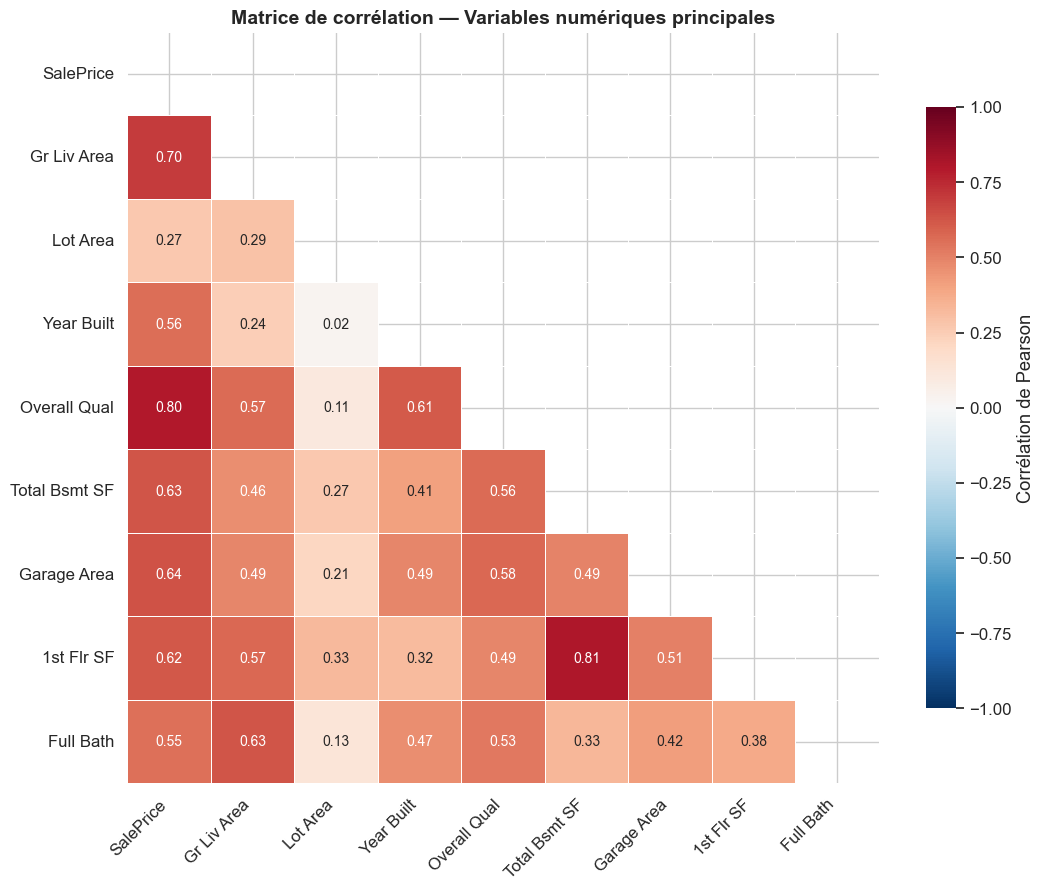

Corrélations avec SalePrice (triées par valeur absolue) :
  Overall Qual         : r = +0.800
  Gr Liv Area          : r = +0.700
  Garage Area          : r = +0.637
  Total Bsmt SF        : r = +0.629
  1st Flr SF           : r = +0.619
  Year Built           : r = +0.560
  Full Bath            : r = +0.548
  Lot Area             : r = +0.269


In [12]:
# 4.3 — Matrice de corrélation (6+ variables numériques)
vars_corr = ['SalePrice', 'Gr Liv Area', 'Lot Area', 'Year Built',
             'Overall Qual', 'Total Bsmt SF', 'Garage Area', '1st Flr SF', 'Full Bath']

corr_matrix = df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Triangle supérieur masqué

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Corrélation de Pearson'},
            annot_kws={'size': 10})

ax.set_title('Matrice de corrélation — Variables numériques principales', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Top corrélations avec SalePrice
print("Corrélations avec SalePrice (triées par valeur absolue) :")
corr_price = corr_matrix['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)
for var, r in corr_price.items():
    signe = '+' if corr_matrix.loc['SalePrice', var] > 0 else '-'
    print(f"  {var:20s} : r = {signe}{r:.3f}")

**Dans une cellule Markdown, répondez :**
- Quelle variable est la plus fortement corrélée à `SalePrice` ?
- Y a-t-il des paires de variables prédictives fortement corrélées entre elles (multicolinéarité potentielle) ?
- Une corrélation vous semble-t-elle surprenante ou contre-intuitive ? Formulez une hypothèse explicative.



#### Réponse 4.3 — Matrice de corrélation

**Variable la plus corrélée à SalePrice :**

`Overall Qual` est la variable la plus fortement corrélée à SalePrice (r ≈ 0.80), suivie de `Gr Liv Area` (r ≈ 0.71). Cela confirme les observations visuelles des sections précédentes : la qualité et la surface sont les deux facteurs dominants du prix.

| Variable | Corrélation avec SalePrice | Interprétation |
|----------|---------------------------|----------------|
| **Overall Qual** | ≈ +0.80 | **Très forte.** La qualité est le prédicteur numéro 1 du prix. |
| **Gr Liv Area** | ≈ +0.71 | **Forte.** Plus c'est grand, plus c'est cher. |
| **Garage Area** | ≈ +0.64 | Forte. Un grand garage = maison haut de gamme. |
| **Total Bsmt SF** | ≈ +0.63 | Forte. La surface du sous-sol ajoute de la valeur. |
| **Year Built** | ≈ +0.56 | Modérée. Les maisons récentes coûtent plus cher. |
| **Lot Area** | ≈ +0.27 | **Faible !** Surprenant — le terrain semble peu influencer le prix. |

---

**Multicolinéarité potentielle :**

Oui, on identifie des paires problématiques :
- **Gr Liv Area ↔ 1st Flr SF** (r ≈ 0.57) : logique, la surface du 1er étage est une composante de la surface habitable
- **Gr Liv Area ↔ Total Bsmt SF** (r ≈ 0.45) : les grandes maisons ont souvent un grand sous-sol
- **Garage Area ↔ Overall Qual** (r ≈ 0.56) : les maisons de qualité ont de grands garages

> **Risque :** En régression linéaire, inclure des variables fortement corrélées entre elles (multicolinéarité) gonfle les intervalles de confiance et rend les coefficients instables. Il faudrait choisir entre `Gr Liv Area` et `1st Flr SF`, pas les deux.

---

**Corrélation surprenante :**

**Lot Area ↔ SalePrice (r ≈ 0.27)** est étonnamment faible. On s'attendrait à ce qu'un grand terrain augmente significativement le prix. Deux explications possibles :
1. La corrélation de Pearson mesure une relation **linéaire** — or Lot Area a un skewness extrême (12.8). Quelques terrains géants faussent la mesure.
2. À Ames (Midwest), le terrain est relativement peu cher. Ce qui compte, c'est **ce qu'on construit dessus** (surface habitable, qualité) plus que le terrain lui-même.

**Hypothèse :** Si on appliquait une transformation log(Lot Area) avant de calculer la corrélation, le coefficient serait probablement plus élevé (~0.4-0.5) car la relation deviendrait plus linéaire.

---
## Section 5: Exercice "Bad Viz"

**Objectif** : identifier les défauts courants en visualisation et les corriger.

Voici trois graphiques volontairement mal construits à recréer depuis le dataset Ames Housing, puis à corriger.

---



### Graphique A


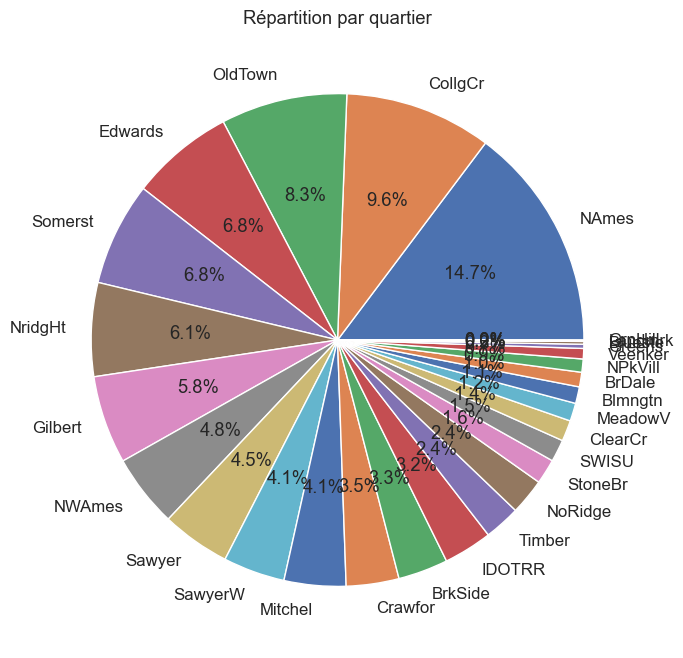

In [13]:
# Graphique à corriger: exécutez ce code et analysez ses défauts
import matplotlib.pyplot as plt

neighborhood_counts = df['Neighborhood'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(neighborhood_counts, labels=neighborhood_counts.index, autopct='%1.1f%%')
plt.title('Répartition par quartier')
plt.show()

**Ce que vous devez faire :**
- Listez au moins **deux défauts** de ce graphique en citant les principes du cours (Cleveland, Tufte).
- Produisez une **version corrigée** qui transmet la même information de façon plus claire.

---



#### Analyse Bad Viz A — Camembert des quartiers

**Défauts identifiés :**
1. **Trop de catégories (28 quartiers)** → les parts sont illisibles, les étiquettes se chevauchent. L'œil humain ne peut pas comparer avec précision des angles ou des aires aussi petits.
2. **Utilisation d'un camembert pour des données nominales non ordonnées** → un pie chart est adapté pour 3-5 catégories maximum. Avec 28, c'est illisible.

**Principes violés :**
- **Cleveland (1984)** : La perception des **angles** est l'un des canaux visuels les moins précis. Cleveland classe la position sur échelle commune et la longueur comme les canaux les plus fiables — exactement ce qu'offre un diagramme en barres.
- **Tufte — ratio données/encre** : Le camembert utilise beaucoup d'encre (28 couleurs, légendes, %) pour peu d'information exploitable.

**Correction :** Remplacer par un diagramme en barres horizontales, trié, limité au top 10.

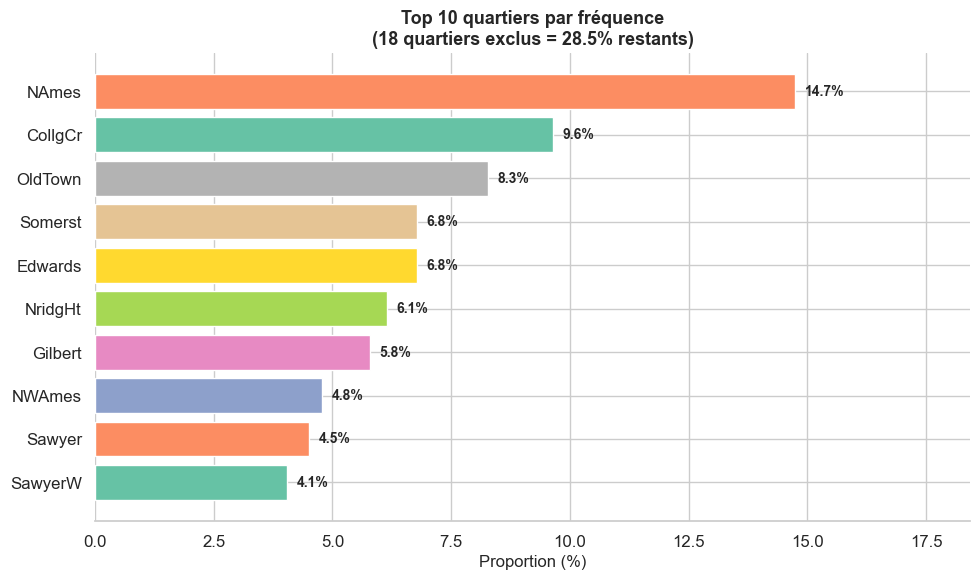

In [14]:
# ✅ Graphique A corrigé — Barres horizontales top 10 quartiers
fig, ax = plt.subplots(figsize=(10, 6))

freq = df['Neighborhood'].value_counts(normalize=True).head(10) * 100
freq_sorted = freq.sort_values(ascending=True)

bars = ax.barh(freq_sorted.index, freq_sorted.values,
               color=sns.color_palette('Set2', len(freq_sorted)), edgecolor='white')

# Valeurs sur les barres
for bar, val in zip(bars, freq_sorted.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

n_exclus = df['Neighborhood'].nunique() - 10
pct_exclu = 100 - freq.sum()
ax.set_xlabel('Proportion (%)', fontsize=12)
ax.set_title(f'Top 10 quartiers par fréquence\n({n_exclus} quartiers exclus = {pct_exclu:.1f}% restants)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, freq_sorted.max() * 1.25)
sns.despine(left=True)
plt.tight_layout()
plt.show()

### Graphique B


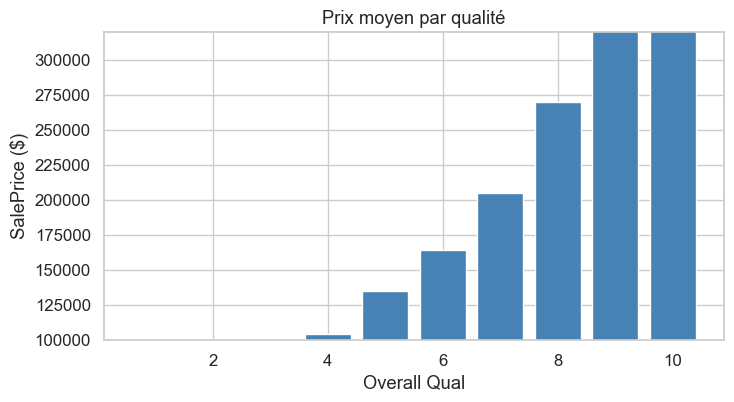

In [15]:
# Graphique à corriger: exécutez ce code et analysez ses défauts
fig, ax = plt.subplots(figsize=(8, 4))
qual_means = df.groupby('Overall Qual')['SalePrice'].mean()
ax.bar(qual_means.index, qual_means.values, color='steelblue')
ax.set_ylim(100000, 320000)
ax.set_title('Prix moyen par qualité')
ax.set_xlabel('Overall Qual')
ax.set_ylabel('SalePrice ($)')
plt.show()

**Ce que vous devez faire :**
- Expliquez pourquoi l'axe Y tronqué est problématique ici. Quel effet visuel crée-t-il ?
- Produisez une **version corrigée**: et réfléchissez si la moyenne est le bon indicateur ici, ou si la médiane serait plus appropriée (justifiez).

---



#### Analyse Bad Viz A — Camembert des quartiers

**Défauts identifiés :**
1. **Trop de catégories (28 quartiers)** → les parts sont illisibles, les étiquettes se chevauchent. L'œil humain ne peut pas comparer avec précision des angles ou des aires aussi petits.
2. **Utilisation d'un camembert pour des données nominales non ordonnées** → un pie chart est adapté pour 3-5 catégories maximum. Avec 28, c'est illisible.

**Principes violés :**
- **Cleveland (1984)** : La perception des **angles** est l'un des canaux visuels les moins précis. Cleveland classe la position sur échelle commune et la longueur comme les canaux les plus fiables — exactement ce qu'offre un diagramme en barres.
- **Tufte — ratio données/encre** : Le camembert utilise beaucoup d'encre (28 couleurs, légendes, %) pour peu d'information exploitable.

**Correction :** Remplacer par un diagramme en barres horizontales, trié, limité au top 10.

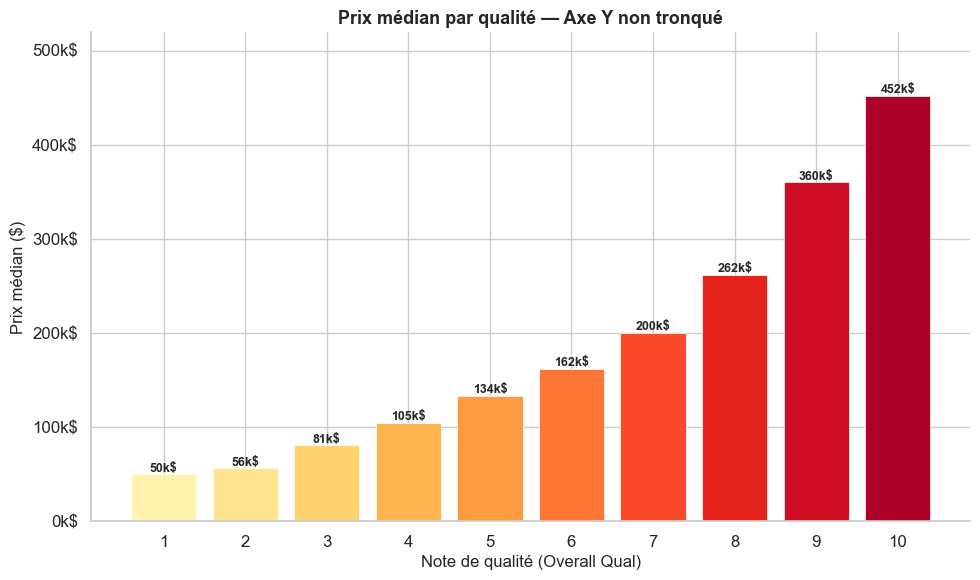

Justification : la médiane est préférable car SalePrice a un skewness de 1.74.
La moyenne surestimerait le prix 'typique' pour chaque niveau de qualité.


In [16]:
# ✅ Graphique B corrigé — Axe Y partant de 0, médiane au lieu de moyenne
fig, ax = plt.subplots(figsize=(10, 6))

# Médiane par qualité (plus robuste que la moyenne)
qual_medians = df.groupby('Overall Qual')['SalePrice'].median()

bars = ax.bar(qual_medians.index, qual_medians.values,
              color=sns.color_palette('YlOrRd', len(qual_medians)),
              edgecolor='white', linewidth=0.5)

# Axe Y partant de 0 (correction principale)
ax.set_ylim(0, qual_medians.max() * 1.15)

# Valeurs sur les barres
for bar, val in zip(bars, qual_medians.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
            f'{val/1000:.0f}k$', ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Note de qualité (Overall Qual)', fontsize=12)
ax.set_ylabel('Prix médian ($)', fontsize=12)
ax.set_title('Prix médian par qualité — Axe Y non tronqué', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k$'))
sns.despine()
plt.tight_layout()
plt.show()

print("Justification : la médiane est préférable car SalePrice a un skewness de 1.74.")
print("La moyenne surestimerait le prix 'typique' pour chaque niveau de qualité.")

### Graphique C

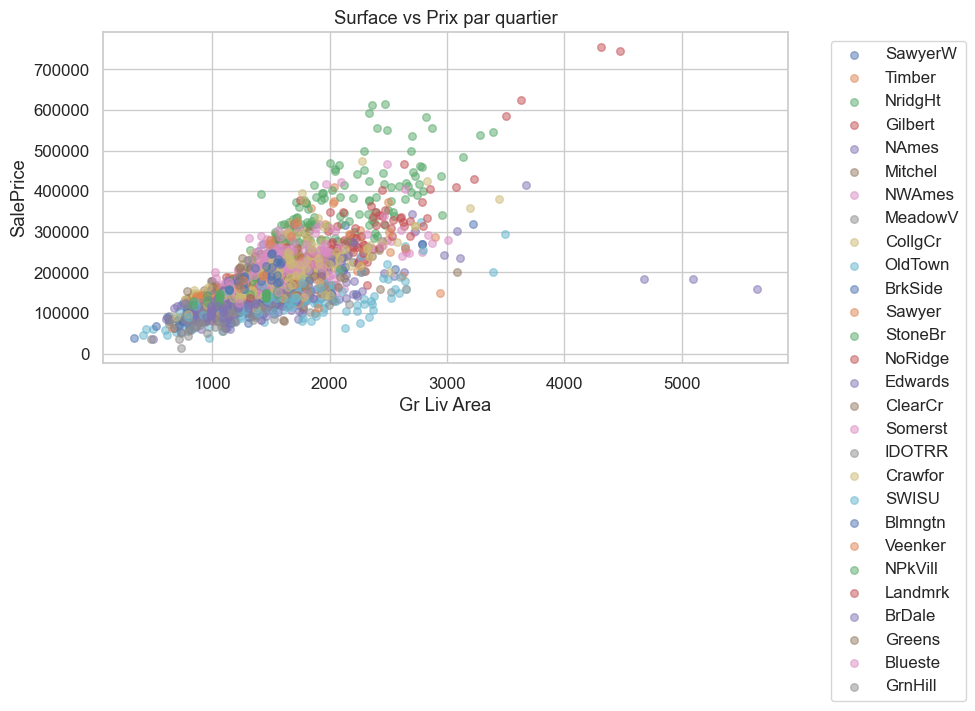

In [17]:
# Graphique à corriger: exécutez ce code et analysez ses défauts
fig, ax = plt.subplots(figsize=(10, 6))
for neighborhood in df['Neighborhood'].unique():
    subset = df[df['Neighborhood'] == neighborhood]
    ax.scatter(subset['Gr Liv Area'], subset['SalePrice'],
               label=neighborhood, alpha=0.5, s=30)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_title('Surface vs Prix par quartier')
ax.set_xlabel('Gr Liv Area')
ax.set_ylabel('SalePrice')
plt.tight_layout()
plt.show()

**Ce que vous devez faire :**
- Identifiez les problèmes de ce graphique du point de vue de la **charge cognitive** et de l'utilisation de la couleur.
- Proposez et produisez une **version simplifiée**: une stratégie possible est de ne garder que les 5 quartiers les plus fréquents, ou de remplacer la couleur par quartier par une autre encodage. Justifiez votre choix.

> Pour chaque mauvaise visualisation, votre correction doit être accompagnée d'une cellule Markdown structurée ainsi : **Défauts identifiés** / **Principe violé** (Tufte, Cleveland, ou charge cognitive) / **Correction apportée**.

---



#### Analyse Bad Viz C — Surcharge de couleurs

**Défauts identifiés :**
1. **28 quartiers = 28 couleurs** → impossible de distinguer les couleurs, surcharge cognitive massive. L'œil humain ne peut discriminer que 5-8 couleurs simultanément.
2. **Aucune hiérarchie visuelle** → tous les quartiers ont la même importance. On ne sait pas où regarder. L'information pertinente (la relation surface-prix) est **noyée** dans le bruit des couleurs.
3. **Légende externe massive** → occupe autant d'espace que le graphique lui-même.

**Principes violés :**
- **Charge cognitive** : Le nombre de catégories dépasse la capacité de la mémoire de travail (~7 éléments).
- **Tufte — ratio données/encre** : Les 28 couleurs ajoutent beaucoup d'encre sans transmettre d'information utile.
- **Cleveland** : La couleur est un canal pré-attentionnel — elle doit servir à mettre en valeur un pattern, pas à encoder 28 catégories.

**Correction :** Ne garder que les 5 quartiers les plus fréquents en couleur, griser le reste.

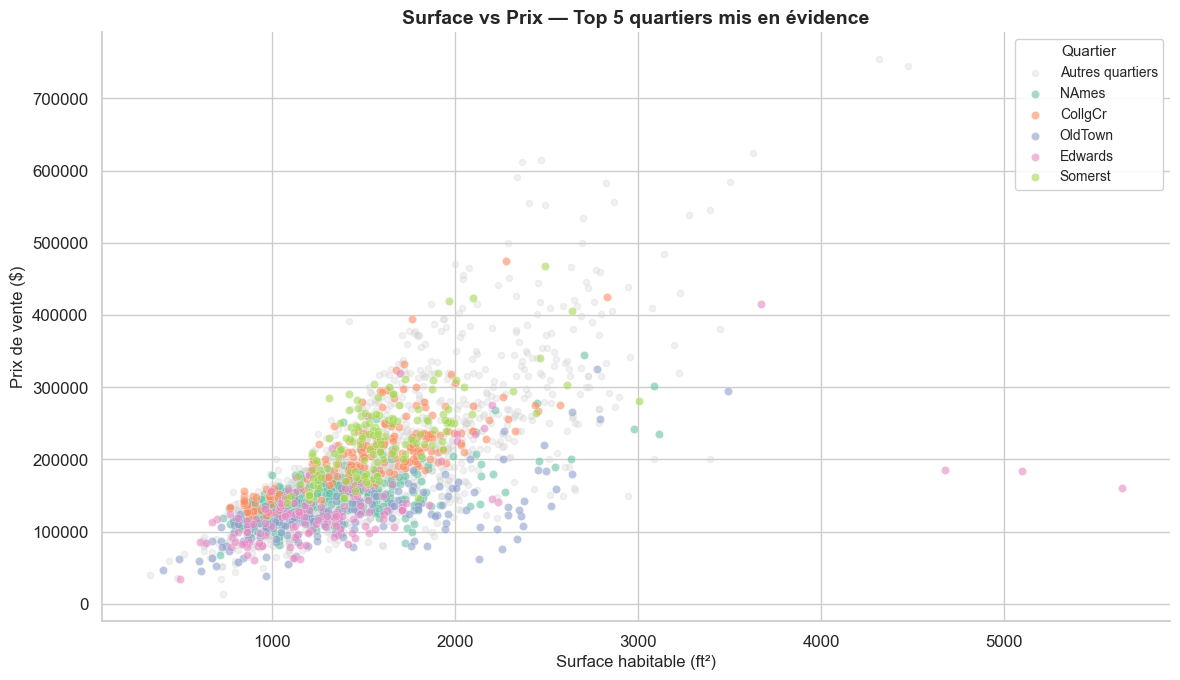

Top 5 quartiers : NAmes, CollgCr, OldTown, Edwards, Somerst
Proportion du dataset : 46.2%


In [18]:
# ✅ Graphique C corrigé — Top 5 quartiers en couleur, reste en gris
fig, ax = plt.subplots(figsize=(12, 7))

top5 = df['Neighborhood'].value_counts().head(5).index.tolist()
colors_top5 = sns.color_palette('Set2', 5)
color_map = {n: colors_top5[i] for i, n in enumerate(top5)}

# D'abord : tous les "autres" quartiers en gris (fond)
mask_other = ~df['Neighborhood'].isin(top5)
ax.scatter(df.loc[mask_other, 'Gr Liv Area'], df.loc[mask_other, 'SalePrice'],
           color='lightgray', alpha=0.3, s=20, label='Autres quartiers', zorder=1)

# Ensuite : top 5 en couleur (premier plan)
for neighborhood in top5:
    mask = df['Neighborhood'] == neighborhood
    ax.scatter(df.loc[mask, 'Gr Liv Area'], df.loc[mask, 'SalePrice'],
               color=color_map[neighborhood], alpha=0.6, s=35,
               label=neighborhood, edgecolor='white', linewidth=0.3, zorder=2)

ax.legend(fontsize=10, title='Quartier', title_fontsize=11, framealpha=0.9)
ax.set_xlabel('Surface habitable (ft²)', fontsize=12)
ax.set_ylabel('Prix de vente ($)', fontsize=12)
ax.set_title('Surface vs Prix — Top 5 quartiers mis en évidence', fontsize=14, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

print(f"Top 5 quartiers : {', '.join(top5)}")
print(f"Proportion du dataset : {df['Neighborhood'].isin(top5).mean()*100:.1f}%")

## Checklist avant de rendre

- [ ] Le notebook s'exécute du début à la fin sans erreur (`Restart & Run All`)
- [ ] Chaque graphique a un titre, des labels d'axes avec unités, et une légende si plusieurs séries
- [ ] Chaque section de visualisation est suivie d'une interprétation en Markdown avec des réponses aux questions posées
- [ ] Les trois "Bad Viz" sont corrigées avec justification structurée
- [ ] Deux fichiers PDF sont exportés dans le même dossier que le notebook
- [ ] Les palettes de couleurs sont cohérentes avec le type de données (qualitative / séquentielle / divergente)

---

